# Fórmula 1 — Análise Exploratória

Objetivos:
- entender padrões históricos;
- analisar impacto do grid;
- identificar pilotos/equipes dominantes;
- medir previsibilidade das corridas.

## Dicionário de dados

| Coluna | Tipo | Descrição |
|---|---|---|
| `Season` | int | Ano da temporada |
| `Round` | int | Round da classificação |
| `Race Name` | string | Nome da corrida |
| `Driver Name` | string | Nome completo do piloto no formato `"Nome, Sobrenome` |
| `Team` | string | Nome da equipe |
| `Grid` | int | Posição no grid |
| `Position` | int | Posição após o fim da corrida |
| `Points` | float | Pontuação de cada round |
| `Laps` | int | Quantidade de voltas da corrida |
| `Status` | string | Status da corrida |
| `Time` | string | Tempo de volta |
| `Fastest Lap` | string | Tempo da volta mais rápida |
| `Positions Gained` | int | Quantas posições alcançadas em relação ao grid inicial |
| `Is Podium` | bool | Identifica se o piloto está no pódio |
| `Is Top 10` | bool | Identifica se o piloto está no top 10 |
| `Race Efficiency` | float | Identifica a eficiência do piloto em relação à posição final |
| `Did finish` | bool | Identifica se o piloto finalizou a corrida |

 ## Imports e Configurações

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

Shape: (25939, 17)

Colunas e tipos:
 season                int64
round                 int64
race_name               str
driver_name             str
team                    str
grid                  int64
position              int64
points              float64
laps                  int64
status                  str
time                    str
fastest_lap             str
positions_gained      int64
is_podium              bool
is_top10               bool
race_efficiency     float64
did_finish             bool
dtype: object


## Leitura dos dados

In [ ]:
base_dir = Path().cwd().parent / "data" / "processed" / "f1_results_processed.csv"

df = pd.read_csv(base_dir)

## Definição de função de plot

In [100]:
def plot_bar(series, title, xlabel, ylabel):
    plt.figure(figsize=(12, 6))
    plt.bar(series.index.astype(str), series.values)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.xticks(rotation=45)

    for i, value in enumerate(series.values):
        plt.text(i, value, str(round(value, 1)), ha="center")

    plt.tight_layout()
    plt.show()

# Exploração dos dados

##### Quais são os pilotos com a maior pontuação das temporadas?

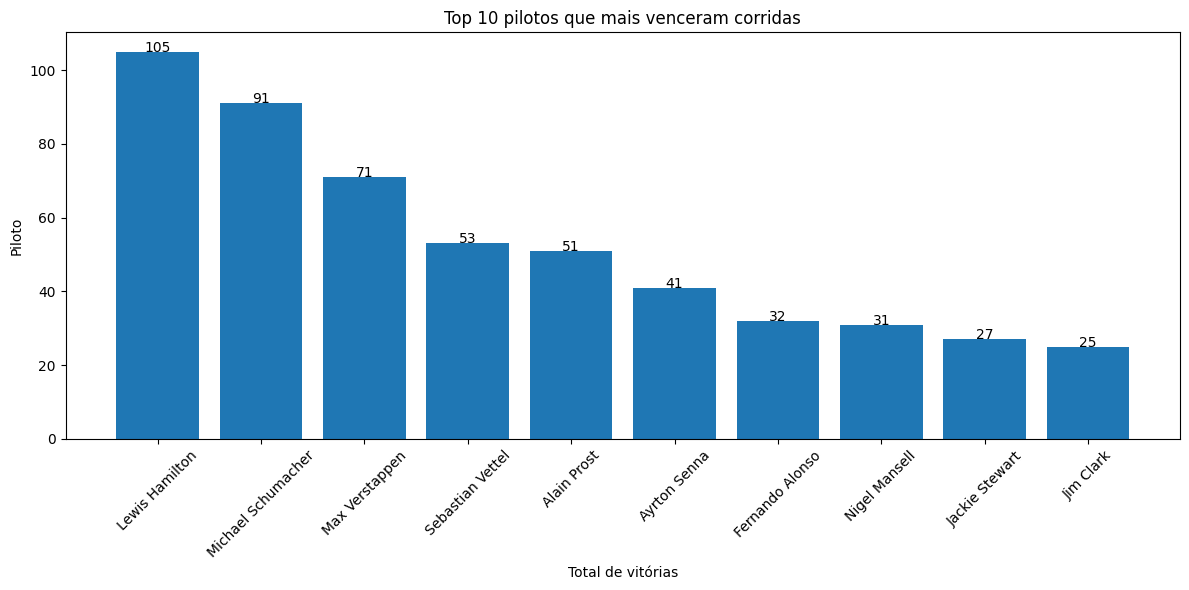

In [ ]:
# Top 10 pilotos com mais vitórias
top_wins = (
    df[df["position"] == 1]["driver_name"]
    .value_counts()
    .head(10)
)

plot_bar(top_wins,
    "Top 10 pilotos que mais venceram corridas",
    "Total de vitórias",
    "Piloto"
)

#### Quem são os pilotos com maior participação em pódios? 

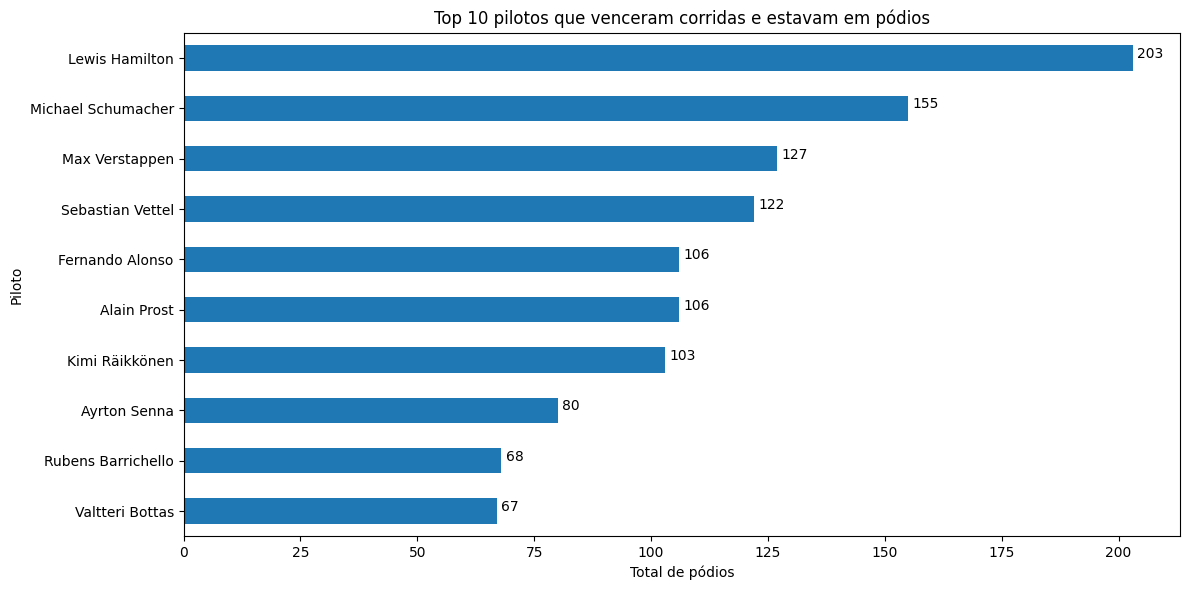

In [ ]:
# Top 10 pilotos com mais pódios
top_podiums = (
    df[df["is_podium"]]["driver_name"]
    .value_counts()
    .head(10)
)
plot_bar(top_podiums,
    "Top 10 pilotos que venceram corridas e estavam em pódios",
    "Total de pódios",
    "Piloto"
)

#### Quais são as equipes com maior número de pontos

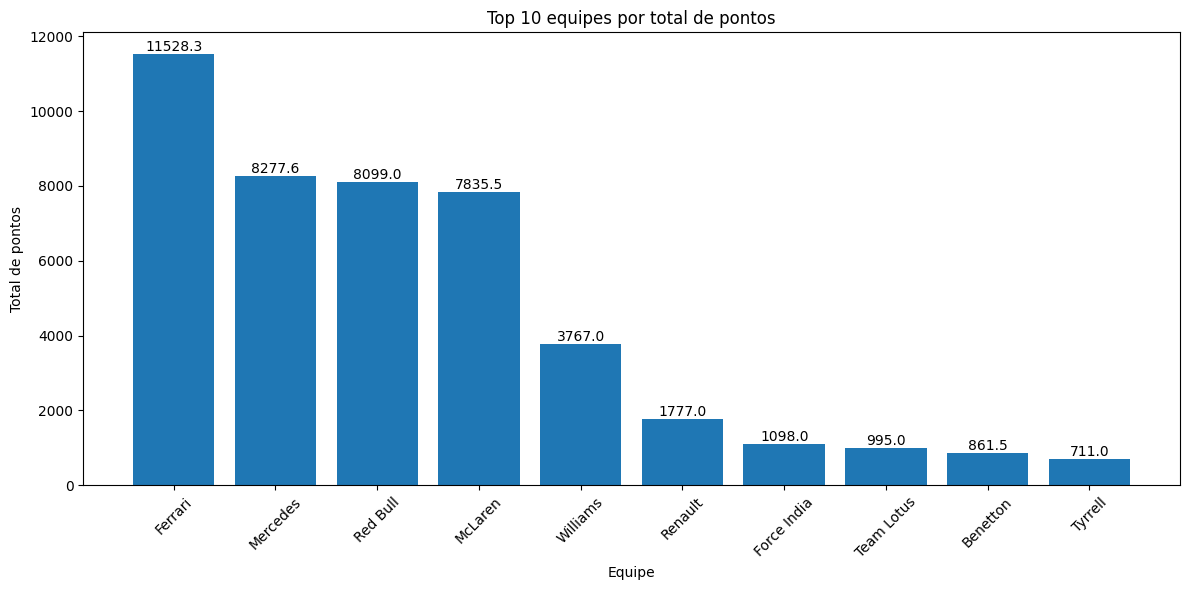

In [ ]:
# Top 10 equipes com mais pontos
top_teams = (
    df.groupby("team")["points"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plot_bar(top_teams,
    "Top 10 equipes por total de pontos",
    "Equipe",
    "Total de pontos"
)

#### Quais são as equipes com maior número de vitórias

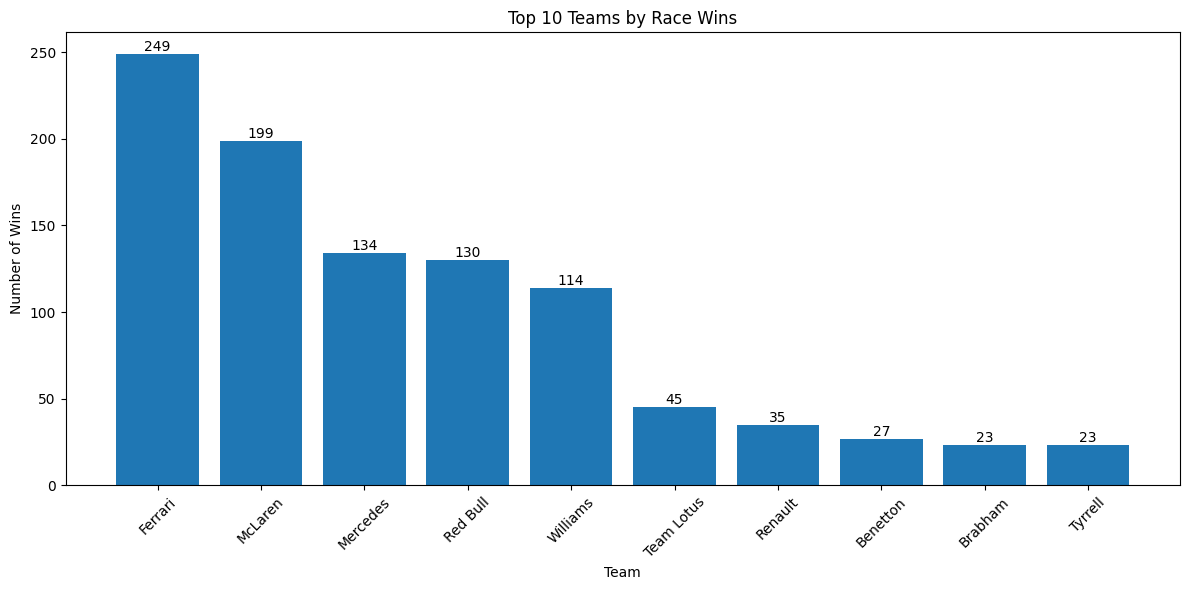

In [ ]:
# Vitórias por equipe
top_winning_teams = (
    df[df["position"] == 1]["team"]
    .value_counts()
    .head(10)
)
plot_bar(top_winning_teams,
    "Top 10 equipes por vitórias",
    "Equipe",
    "Total de vitórias"
)

### O Grid influencia vitórias?
#### Hipótese:
##### Pilotos largando nas primeiras posições vencem mais.

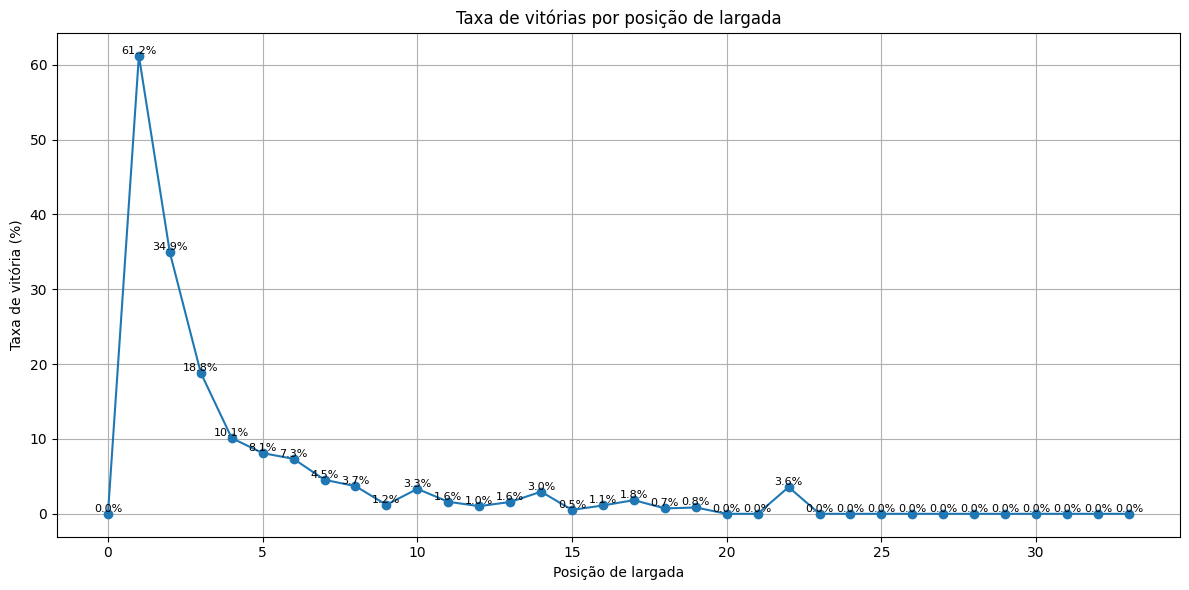

In [ ]:
# Traz pilotos que finalizaram a corrida (existem os que não finalizaram, bateram, acabou gasolina, etc)
df_finished = df[df["did_finish"] == True]

# Vitórias por grid
grid_wins = (
    df_finished[df_finished["position"] == 1]
    .groupby("grid")
    .size()
    .sort_index()
)

# Total de finalizações por grid de largada
grid_total = (
    df_finished.groupby("grid")
    .size()
    .sort_index()
)

# Taxa de vitória por posição de grid
win_rate = (grid_wins / grid_total * 100).fillna(0)

plt.figure(figsize=(12, 6))
plt.plot(win_rate.index, win_rate.values, marker="o")

plt.title("Taxa de vitórias por posição de largada")
plt.xlabel("Posição de largada")
plt.ylabel("Taxa de vitória (%)")


plt.grid(True)

for x, y in zip(win_rate.index, win_rate.values):
    plt.text(x, y, f"{y:.1f}%", fontsize=8, ha="center", va="bottom")

plt.tight_layout()
plt.show()

### A taxa de vitória cai drasticamente após o top 3 do Grid.

### Essa correlação muda entre temporadas de Grid vs Posição vencedora?
#### Hipótese:
##### Na fórmula 1 moderna isso é um fato ou não?

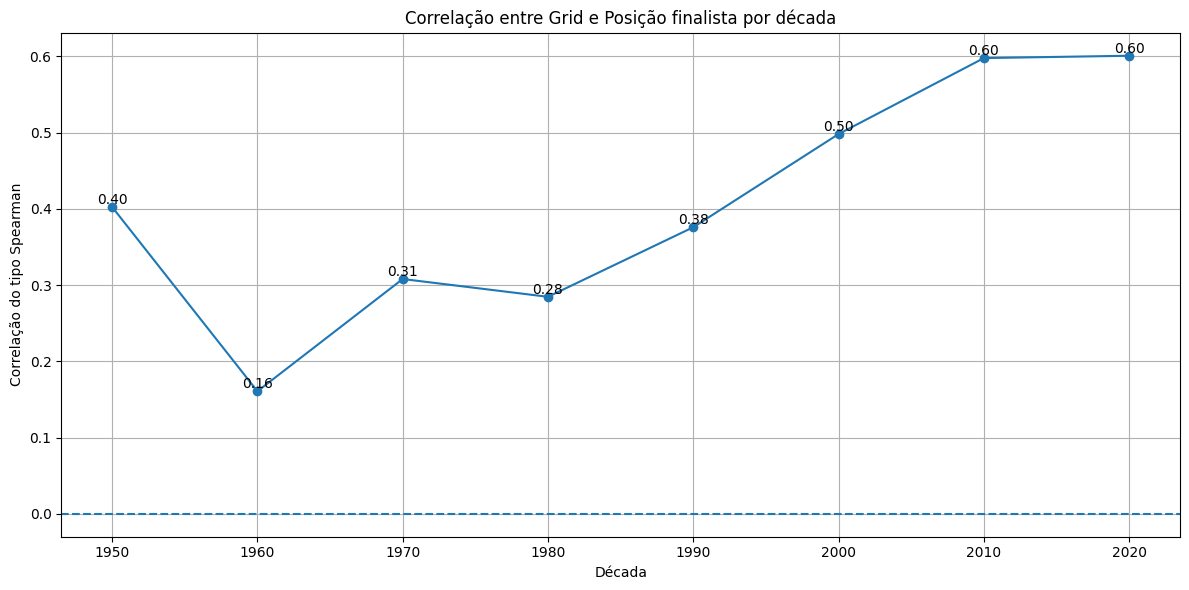

In [96]:
# Correlação anual entre grid e posição final
season_corr = (
    df.groupby("season")[["grid", "position"]]
    .corr(method="spearman")
    .iloc[0::2, -1]
    .reset_index()
)

season_corr = season_corr.rename(columns={"position": "correlation"})

# Separa a season em décadas
season_corr["decade"] = (season_corr["season"] // 10) * 10

# Média da correlação por década
decade_corr = (
    season_corr.groupby("decade")["correlation"]
    .mean()
)

plt.figure(figsize=(12, 6))
plt.plot(decade_corr.index, decade_corr.values, marker="o")

# Labels
plt.title("Correlação entre Grid e Posição finalista por década")
plt.xlabel("Década")
plt.ylabel("Correlação do tipo Spearman")

# Linha horizontal para referência
plt.axhline(0, linestyle="--")

for x, y in zip(decade_corr.index, decade_corr.values):
    plt.text(x, y, f"{y:.2f}", ha="center", va="bottom")

plt.grid(True)

plt.tight_layout()
plt.show()

# Conclusões

- Pole positions possuem forte correlação com vitórias;
- Décadas recentes mostram maior previsibilidade;
- Equipes dominantes concentram grande parte dos pontos;
- A F1 moderna depende mais de qualifying.